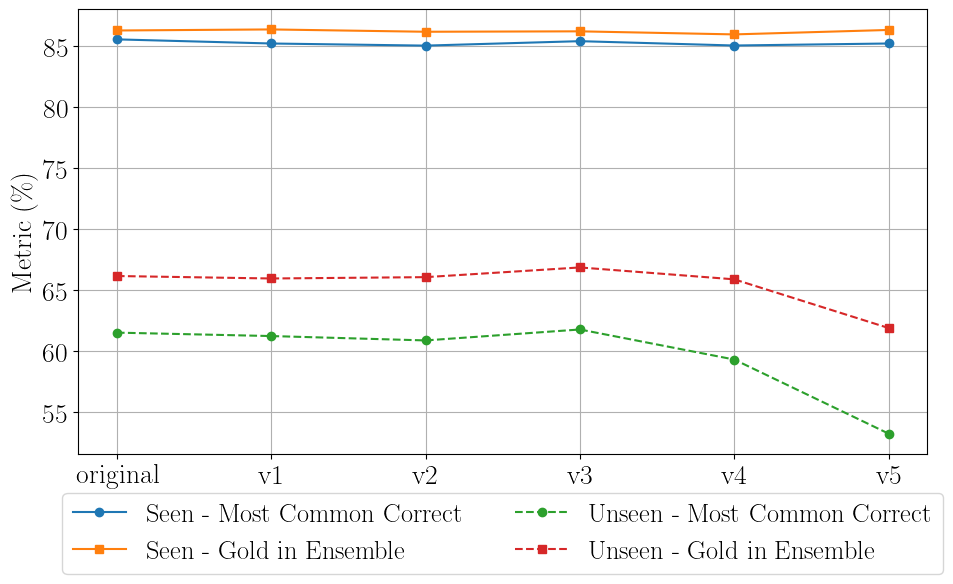

In [28]:
import json
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
# sns.set_palette("viridis")
# Path to the uploaded JSON file
file_path = '/Users/alexandrucoca/work/dev/robust-dst-v2/hyps/d3st/seed_240463_d3st_v15_corpus_description_oracle/ensemble.1-3/test/version_10/metrics.json'

# Load the JSON data
with open(file_path, 'r') as f:
    data = json.load(f)

# Define the variants in the desired order
variants = ['original', 'v1', 'v2', 'v3', 'v4', 'v5']

# Initialize lists to store metric values
seen_most_common = []
seen_gold = []
unseen_most_common = []
unseen_gold = []

# Extract the required metrics for each variant
for v in variants:
    seen_slot_values = data[v]['seen']['slot_values']
    unseen_slot_values = data[v]['unseen']['slot_values']
    
    seen_most_common.append(seen_slot_values['most_common_correct'])
    seen_gold.append(seen_slot_values['gold_in_ensemble_predictions'])
    unseen_most_common.append(unseen_slot_values['most_common_correct'])
    unseen_gold.append(unseen_slot_values['gold_in_ensemble_predictions'])

# Create a wide DataFrame for a clear tabular view
df_metrics = pd.DataFrame({
    'variant': variants,
    'seen_most_common_correct': seen_most_common,
    'seen_gold_in_ensemble_predictions': seen_gold,
    'unseen_most_common_correct': unseen_most_common,
    'unseen_gold_in_ensemble_predictions': unseen_gold
})

# Display the DataFrame to the user

# Plot the metrics
plt.figure(figsize=(10, 6))
plt.plot(variants, seen_most_common, marker='o', label='Seen - Most Common Correct')
plt.plot(variants, seen_gold, marker='s', label='Seen - Gold in Ensemble')
plt.plot(variants, unseen_most_common, marker='o', linestyle='--', label='Unseen - Most Common Correct')
plt.plot(variants, unseen_gold, marker='s', linestyle='--', label='Unseen - Gold in Ensemble')

# plt.xlabel('Variant', fontsize=20)
plt.ylabel('Metric (\%)', fontsize=20)
# plt.title('Slot Values Metrics Across Ensemble Variants')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(ncol=2, fontsize=19, loc='lower center', bbox_to_anchor=(0.50, -0.30))
# lg = fig.legend(handles, labels,
#            loc='lower center',
#            bbox_to_anchor=(0.53, -0.15),
#            ncol=3,  # number of columns in the legend
#            fontsize=20)
plt.grid(True)
plt.tight_layout()
save_path="../reports/figures/ensemble_metrics.pdf"
plt.savefig(save_path, format="pdf", dpi=300, bbox_inches='tight')
plt.show()
